# PACE vs Vanilla GRPO on MBPP (Qwen3-1.7B)

This notebook compares **PACE** (Persistent Advantage-weighted Curriculum Exploration) against **vanilla GRPO** for code generation on the MBPP benchmark.

**Setup:**
- Base model: `Qwen/Qwen3-1.7B` with LoRA (r=32)
- Training data: HuggingFace MBPP train split (374 problems)
- Reward: binary code execution (pass/fail against test cases)
- G=2 generations per prompt, `num_iterations=4`
- Batch size 16, gradient accumulation 4, lr=2.5e-5
- Evaluation: MBPP+ (evalplus, 378 problems, temperature=0.0)

**Runs:**
- **PACE** (v9): 200 steps, baseline warm-start, curriculum enabled
- **Vanilla** (v10): 200 steps, no baseline, no curriculum

## 1. Setup & Load Data

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

BASE_DIR = Path('/home/jovyan/Finetunehub')

# Base model scores (no fine-tuning)
BASE_MBPP = 0.6005
BASE_MBPP_PLUS = 0.5238

In [2]:
# Load evaluation results
def load_eval_curve(eval_dir, steps):
    """Load MBPP/MBPP+ pass@1 from summary.json files."""
    mbpp, mbpp_plus = [], []
    valid_steps = []
    for s in steps:
        p = Path(eval_dir) / f'cp{s}' / 'summary.json'
        if p.exists():
            with open(p) as f:
                d = json.load(f)
            mbpp.append(d['mbpp_pass@1'])
            mbpp_plus.append(d['mbpp_plus_pass@1'])
            valid_steps.append(s)
    return np.array(valid_steps), np.array(mbpp), np.array(mbpp_plus)

# Load training logs from trainer_state.json
def load_training_logs(output_dir, max_step=None):
    """Load training metrics from the final checkpoint's trainer_state.json."""
    checkpoints = sorted(Path(output_dir).glob('checkpoint-*'), key=lambda p: int(p.name.split('-')[1]))
    state_file = checkpoints[-1] / 'trainer_state.json'
    with open(state_file) as f:
        state = json.load(f)
    logs = state['log_history']
    if max_step:
        logs = [e for e in logs if e.get('step', 0) <= max_step]
    return logs

# PACE v9 (first 200 steps)
pace_steps, pace_mbpp, pace_mbpp_plus = load_eval_curve(
    BASE_DIR / 'eval_results/v9_500steps', range(25, 225, 25))
pace_logs = load_training_logs(BASE_DIR / 'output/bolt_g2_s81_pace_mbpp_v9_500steps', max_step=200)

# Vanilla v10 (200 steps)
van_steps, van_mbpp, van_mbpp_plus = load_eval_curve(
    BASE_DIR / 'eval_results/v10_vanilla_200steps', range(25, 225, 25))
van_logs = load_training_logs(BASE_DIR / 'output/vanilla_g2_s81_mbpp_v10_200steps')

print(f'PACE: {len(pace_steps)} checkpoints (steps {pace_steps[0]}-{pace_steps[-1]})')
print(f'Vanilla: {len(van_steps)} checkpoints (steps {van_steps[0]}-{van_steps[-1]})')

PACE: 8 checkpoints (steps 25-200)
Vanilla: 8 checkpoints (steps 25-200)


## 2. Evaluation Curves (MBPP+ Pass@1)

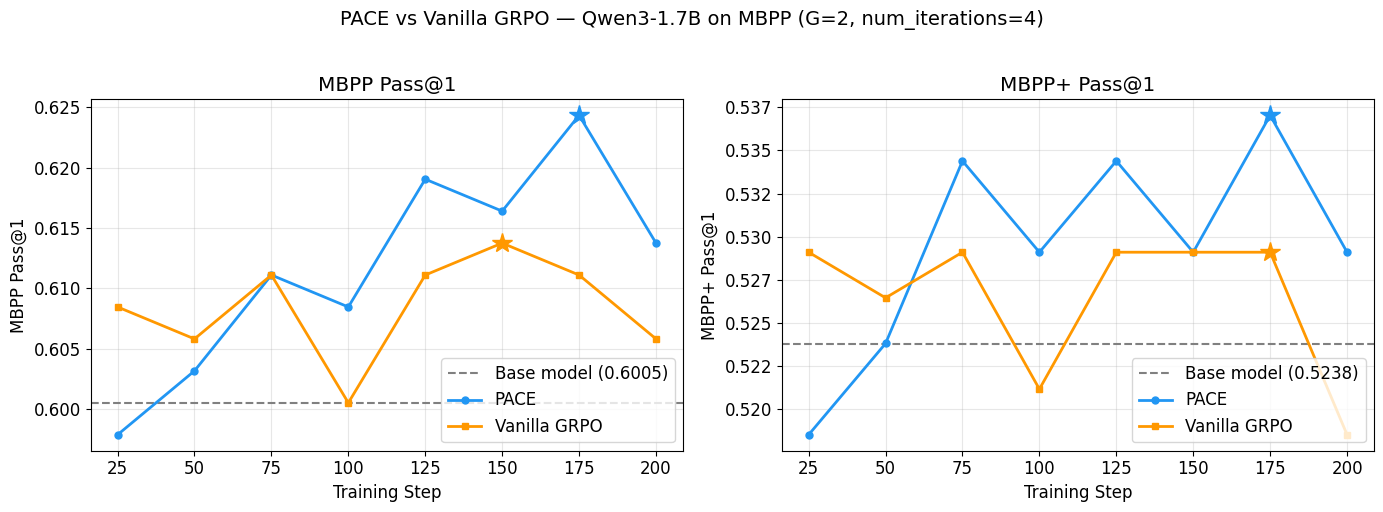


Best PACE:    step 175 — MBPP 0.6243, MBPP+ 0.5370
Best Vanilla: step 175 — MBPP 0.6111, MBPP+ 0.5291
Base model:               MBPP 0.6005, MBPP+ 0.5238


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def best_idx(vals):
    """Index of max value, preferring later steps on ties."""
    return int(np.where(vals == vals.max())[0][-1])

for ax, metric, pace_vals, van_vals, base_val, title in [
    (axes[0], 'MBPP Pass@1', pace_mbpp, van_mbpp, BASE_MBPP, 'MBPP Pass@1'),
    (axes[1], 'MBPP+ Pass@1', pace_mbpp_plus, van_mbpp_plus, BASE_MBPP_PLUS, 'MBPP+ Pass@1'),
]:
    ax.axhline(base_val, color='gray', linestyle='--', linewidth=1.5, label=f'Base model ({base_val:.4f})')
    ax.plot(pace_steps, pace_vals, 'o-', color='#2196F3', linewidth=2, markersize=5, label='PACE')
    ax.plot(van_steps, van_vals, 's-', color='#FF9800', linewidth=2, markersize=5, label='Vanilla GRPO')

    # Mark best checkpoints
    pace_best = best_idx(pace_vals)
    van_best = best_idx(van_vals)
    ax.plot(pace_steps[pace_best], pace_vals[pace_best], '*', color='#2196F3', markersize=15, zorder=5)
    ax.plot(van_steps[van_best], van_vals[van_best], '*', color='#FF9800', markersize=15, zorder=5)

    ax.set_xlabel('Training Step')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

fig.suptitle('PACE vs Vanilla GRPO — Qwen3-1.7B on MBPP (G=2, num_iterations=4)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/pace_vs_vanilla_eval_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best results
pb = best_idx(pace_mbpp_plus)
vb = best_idx(van_mbpp_plus)
print(f'\nBest PACE:    step {pace_steps[pb]:>3d} — MBPP {pace_mbpp[pb]:.4f}, MBPP+ {pace_mbpp_plus[pb]:.4f}')
print(f'Best Vanilla: step {van_steps[vb]:>3d} — MBPP {van_mbpp[vb]:.4f}, MBPP+ {van_mbpp_plus[vb]:.4f}')
print(f'Base model:               MBPP {BASE_MBPP:.4f}, MBPP+ {BASE_MBPP_PLUS:.4f}')

## 3. Training Dynamics

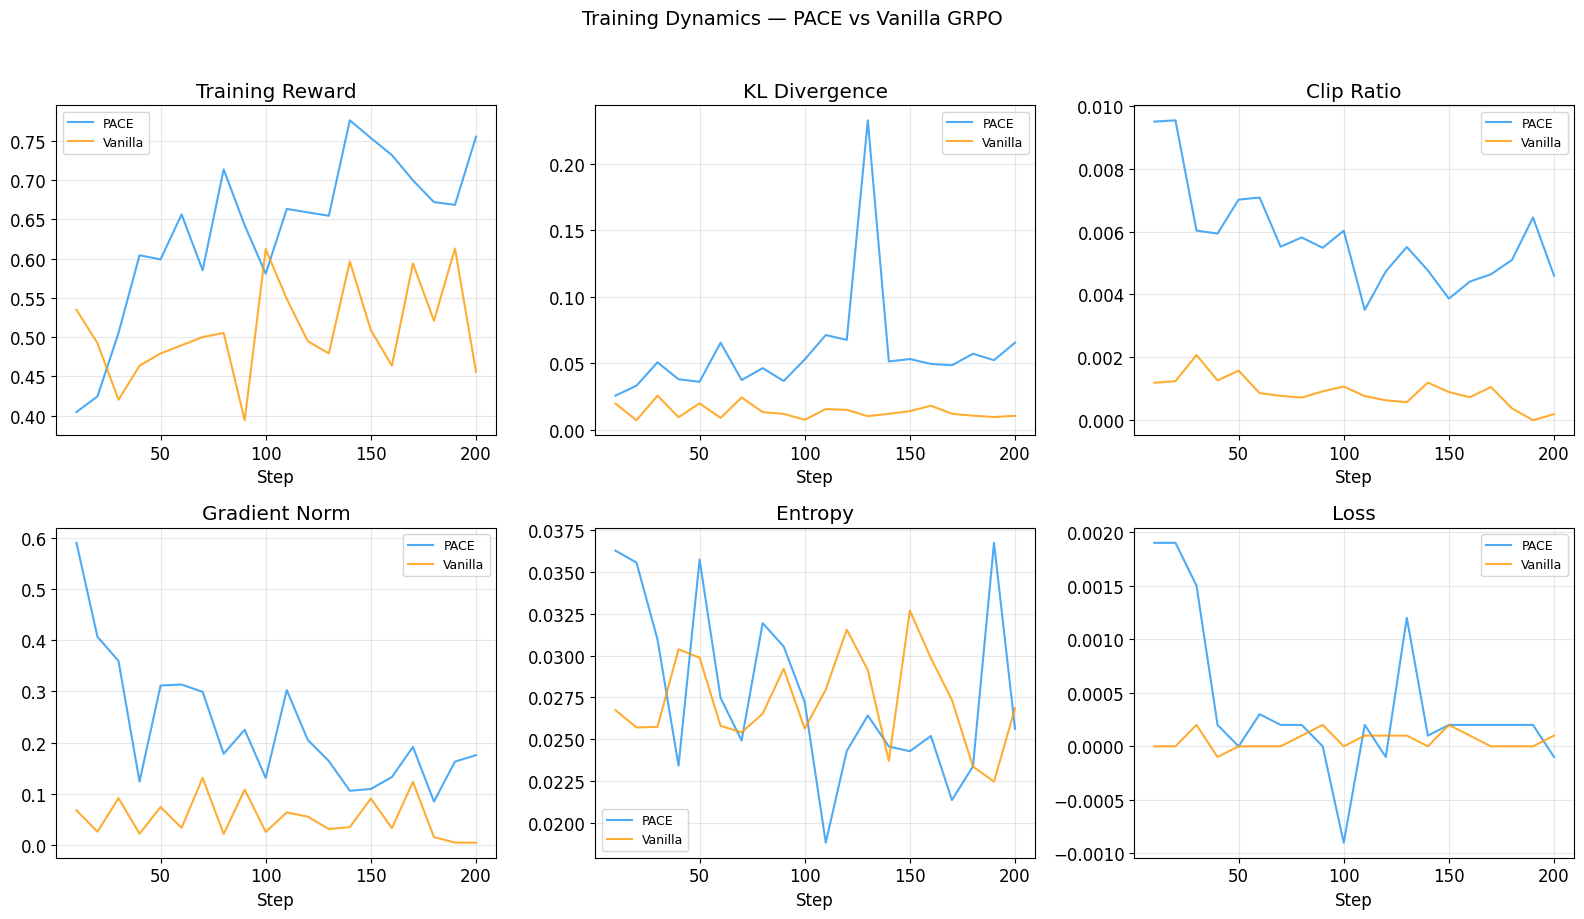

In [4]:
def extract_metric(logs, key):
    """Extract (step, value) pairs for a metric from training logs."""
    steps, vals = [], []
    for entry in logs:
        if key in entry:
            steps.append(entry['step'])
            vals.append(entry[key])
    return np.array(steps), np.array(vals)

metrics = [
    ('reward', 'Training Reward'),
    ('kl', 'KL Divergence'),
    ('clip_ratio/region_mean', 'Clip Ratio'),
    ('grad_norm', 'Gradient Norm'),
    ('entropy', 'Entropy'),
    ('loss', 'Loss'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (key, title) in zip(axes, metrics):
    ps, pv = extract_metric(pace_logs, key)
    vs, vv = extract_metric(van_logs, key)

    ax.plot(ps, pv, '-', color='#2196F3', linewidth=1.5, alpha=0.8, label='PACE')
    ax.plot(vs, vv, '-', color='#FF9800', linewidth=1.5, alpha=0.8, label='Vanilla')
    ax.set_title(title)
    ax.set_xlabel('Step')
    ax.legend(fontsize=9)

fig.suptitle('Training Dynamics — PACE vs Vanilla GRPO', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/pace_vs_vanilla_training_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. PACE Baseline Dynamics

PACE maintains a per-problem baseline $\hat{v}(x)$ that tracks the model's pass rate. The advantage signal $A = r - \hat{v}(x)$ provides learning signal even for degenerate groups (all-pass or all-fail).

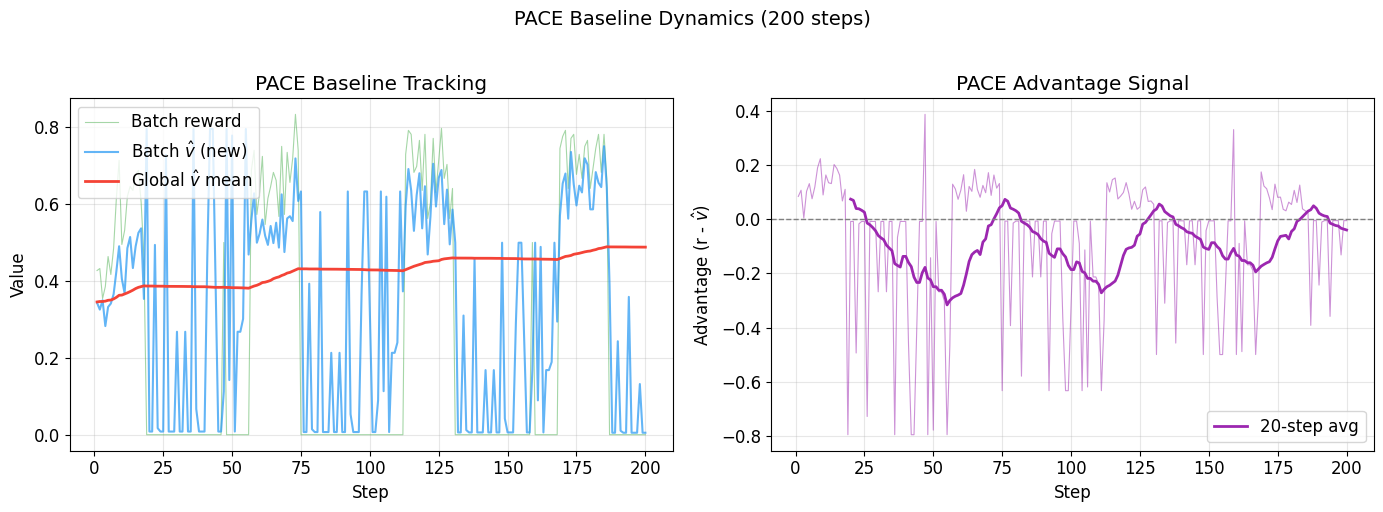

In [5]:
# Load baseline state log (PACE only, first 200 steps)
baseline_log = []
with open(BASE_DIR / 'output/bolt_g2_s81_pace_mbpp_v9_500steps/baseline_state_log.jsonl') as f:
    for line in f:
        entry = json.loads(line)
        if entry['step'] <= 200:
            baseline_log.append(entry)

bl_steps = [e['step'] for e in baseline_log]
bl_vhat_mean = [e['batch_v_hat_new']['mean'] for e in baseline_log]
bl_reward = [e['batch_mean_reward'] for e in baseline_log]
bl_global_mean = [e['global_v_hat']['mean'] for e in baseline_log]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: baseline vs actual reward
ax = axes[0]
ax.plot(bl_steps, bl_reward, '-', color='#4CAF50', alpha=0.5, linewidth=0.8, label='Batch reward')
ax.plot(bl_steps, bl_vhat_mean, '-', color='#2196F3', alpha=0.7, linewidth=1.5, label=r'Batch $\hat{v}$ (new)')
ax.plot(bl_steps, bl_global_mean, '-', color='#F44336', linewidth=2, label=r'Global $\hat{v}$ mean')
ax.set_xlabel('Step')
ax.set_ylabel('Value')
ax.set_title('PACE Baseline Tracking')
ax.legend()

# Right: advantage magnitude (reward - v_hat)
ax = axes[1]
advantages = np.array(bl_reward) - np.array(bl_vhat_mean)
ax.plot(bl_steps, advantages, '-', color='#9C27B0', alpha=0.5, linewidth=0.8)
# Rolling average
window = 20
if len(advantages) > window:
    rolling = np.convolve(advantages, np.ones(window)/window, mode='valid')
    ax.plot(bl_steps[window-1:], rolling, '-', color='#9C27B0', linewidth=2, label=f'{window}-step avg')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Step')
ax.set_ylabel(r'Advantage (r - $\hat{v}$)')
ax.set_title('PACE Advantage Signal')
ax.legend()

fig.suptitle('PACE Baseline Dynamics (200 steps)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('plots/pace_baseline_dynamics_v9.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Results Summary

In [6]:
# Summary table
pb = best_idx(pace_mbpp_plus)
vb = best_idx(van_mbpp_plus)

print('=' * 70)
print('PACE vs Vanilla GRPO — MBPP+ Evaluation (Qwen3-1.7B, LoRA r=32)')
print('=' * 70)
print(f'{"Method":<18} {"Best Step":>10} {"MBPP":>10} {"MBPP+":>10} {"MBPP+ Delta":>12}')
print('-' * 70)
print(f'{"Base model":<18} {"—":>10} {BASE_MBPP:>10.4f} {BASE_MBPP_PLUS:>10.4f} {"—":>12}')
print(f'{"Vanilla GRPO":<18} {van_steps[vb]:>10d} {van_mbpp[vb]:>10.4f} {van_mbpp_plus[vb]:>10.4f} {van_mbpp_plus[vb] - BASE_MBPP_PLUS:>+12.4f}')
print(f'{"PACE":<18} {pace_steps[pb]:>10d} {pace_mbpp[pb]:>10.4f} {pace_mbpp_plus[pb]:>10.4f} {pace_mbpp_plus[pb] - BASE_MBPP_PLUS:>+12.4f}')
print('-' * 70)
print(f'{"PACE vs Vanilla":<18} {"":>10} {pace_mbpp[pb] - van_mbpp[vb]:>+10.4f} {pace_mbpp_plus[pb] - van_mbpp_plus[vb]:>+10.4f}')
print('=' * 70)

PACE vs Vanilla GRPO — MBPP+ Evaluation (Qwen3-1.7B, LoRA r=32)
Method              Best Step       MBPP      MBPP+  MBPP+ Delta
----------------------------------------------------------------------
Base model                  —     0.6005     0.5238            —
Vanilla GRPO              175     0.6111     0.5291      +0.0053
PACE                      175     0.6243     0.5370      +0.0132
----------------------------------------------------------------------
PACE vs Vanilla                  +0.0132    +0.0079


In [7]:
# Full checkpoint-by-checkpoint table
print('\nPACE — All Checkpoints')
print(f'{"Step":>6} | {"MBPP":>8} | {"MBPP+":>8}')
print(f'{"-"*6}-+-{"-"*8}-+-{"-"*8}')
for i, s in enumerate(pace_steps):
    marker = ' *' if pace_mbpp_plus[i] == pace_mbpp_plus.max() else ''
    print(f'{s:>6} | {pace_mbpp[i]:.4f} | {pace_mbpp_plus[i]:.4f}{marker}')

print('\nVanilla GRPO — All Checkpoints')
print(f'{"Step":>6} | {"MBPP":>8} | {"MBPP+":>8}')
print(f'{"-"*6}-+-{"-"*8}-+-{"-"*8}')
for i, s in enumerate(van_steps):
    marker = ' *' if van_mbpp_plus[i] == van_mbpp_plus.max() else ''
    print(f'{s:>6} | {van_mbpp[i]:.4f} | {van_mbpp_plus[i]:.4f}{marker}')


PACE — All Checkpoints
  Step |     MBPP |    MBPP+
-------+----------+---------
    25 | 0.5979 | 0.5185
    50 | 0.6032 | 0.5238
    75 | 0.6111 | 0.5344
   100 | 0.6085 | 0.5291
   125 | 0.6190 | 0.5344
   150 | 0.6164 | 0.5291
   175 | 0.6243 | 0.5370 *
   200 | 0.6138 | 0.5291

Vanilla GRPO — All Checkpoints
  Step |     MBPP |    MBPP+
-------+----------+---------
    25 | 0.6085 | 0.5291 *
    50 | 0.6058 | 0.5265
    75 | 0.6111 | 0.5291 *
   100 | 0.6005 | 0.5212
   125 | 0.6111 | 0.5291 *
   150 | 0.6138 | 0.5291 *
   175 | 0.6111 | 0.5291 *
   200 | 0.6058 | 0.5185


## 6. Train & Evaluate (Reproducibility)

The cells below reproduce the training and evaluation from scratch. **Skip these if you already have the results above.**

In [8]:
import os, sys, yaml, dataclasses, gc, subprocess, torch

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['UNSLOTH_DISABLED'] = '1'
os.chdir('/home/jovyan/Finetunehub')
sys.path.insert(0, '/home/jovyan/Finetunehub/src')

from aligntune.core.rl.config import (
    UnifiedConfig, AlgorithmType, ModelConfig, DatasetConfig,
    TrainingConfig, LoggingConfig, DistributedConfig, RewardConfig,
)

def build_dataclass(cls, raw_dict):
    known = {f.name for f in dataclasses.fields(cls)}
    return cls(**{k: v for k, v in raw_dict.items() if k in known})

def build_config(cfg_dict):
    return UnifiedConfig(
        algo=AlgorithmType(cfg_dict['algo']),
        model=build_dataclass(ModelConfig, cfg_dict['model']),
        datasets=[build_dataclass(DatasetConfig, d) for d in cfg_dict['datasets']],
        rewards=[build_dataclass(RewardConfig, r) for r in cfg_dict.get('rewards', [])],
        train=build_dataclass(TrainingConfig, cfg_dict.get('train', {})),
        logging=build_dataclass(LoggingConfig, cfg_dict.get('logging', {})),
        distributed=build_dataclass(DistributedConfig, cfg_dict.get('distributed', {})),
        chat_template=cfg_dict.get('chat_template'),
    )

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

print('Setup complete.')

Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Setup complete.

### 6a. Train PACE (200 steps)

In [9]:
with open('configs/bolt_mbpp_g2_pace.yaml') as f:
    cfg = yaml.safe_load(f)

# PACE settings
cfg['train']['baseline_warm_start'] = 'baselines/mbpp_train_qwen3_1.7b.json'
cfg['train']['baseline_enabled'] = True
cfg['train']['use_baseline_advantages'] = True
cfg['train']['curriculum_enabled'] = True
cfg['train']['max_steps'] = 200
cfg['train']['num_generations'] = 2
cfg['train']['per_device_batch_size'] = 16
cfg['train']['gradient_accumulation_steps'] = 4
cfg['train']['learning_rate'] = 2.5e-5
cfg['logging']['output_dir'] = 'output/bolt_g2_s81_pace_mbpp_v9_500steps'
cfg['logging']['run_name'] = 'bolt_g2_s81_pace_mbpp_v9_500steps'

config = build_config(cfg)
print(f'PACE training: {config.train.max_steps} steps, G={config.train.num_generations}')
print(f'Output: {config.logging.output_dir}')

from aligntune.backends.trl.rl.bolt.bolt import TRLBoltTrainer
trainer = TRLBoltTrainer(config)
results = trainer.train()
print(f'Done: {results.get("total_steps", "?")} steps')
del trainer
cleanup()

PACE training: 200 steps, G=2

Output: output/bolt_g2_s81_pace_mbpp_v9_500steps

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 34,865,152 || all params: 1,755,440,128 || trainable%: 1.9861

Generating train split:   0%|          | 0/374 [00:00<?, ? examples/s]

...

  v̂=0.996 (N=15.8): mbpp_train_Mbpp/811

  v̂=0.997 (N=16.5): mbpp_train_Mbpp/718

  v̂=0.997 (N=16.5): mbpp_train_Mbpp/741

  v̂=0.997 (N=17.2): mbpp_train_Mbpp/680

Done: 200 steps

### 6b. Train Vanilla GRPO (200 steps)

In [10]:
with open('configs/bolt_mbpp_g2_pace.yaml') as f:
    cfg = yaml.safe_load(f)

# Disable PACE
cfg['train']['baseline_enabled'] = False
cfg['train']['use_baseline_advantages'] = False
cfg['train']['baseline_warm_start'] = None
cfg['train']['curriculum_enabled'] = False
cfg['train']['max_steps'] = 200
cfg['train']['num_generations'] = 2
cfg['train']['per_device_batch_size'] = 16
cfg['train']['gradient_accumulation_steps'] = 4
cfg['train']['learning_rate'] = 2.5e-5
cfg['logging']['output_dir'] = 'output/vanilla_g2_s81_mbpp_v10_200steps'
cfg['logging']['run_name'] = 'vanilla_g2_s81_mbpp_v10_200steps'

config = build_config(cfg)
print(f'Vanilla GRPO training: {config.train.max_steps} steps, G={config.train.num_generations}')
print(f'Output: {config.logging.output_dir}')

from aligntune.backends.trl.rl.bolt.bolt import TRLBoltTrainer
trainer = TRLBoltTrainer(config)
results = trainer.train()
print(f'Done: {results.get("total_steps", "?")} steps')
del trainer
cleanup()

Vanilla GRPO training: 200 steps, G=2

Output: output/vanilla_g2_s81_mbpp_v10_200steps

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 34,865,152 || all params: 1,755,440,128 || trainable%: 1.9861

🔍 Auto-detected dataset format: 'mbpp' in 'mbpp'

...

      CODE:  The list can contain duplicate elements and negative numbers. The function should return the second smallest number, even if there are multiple instances of the second smallest number. For example, in the list [5, 3, 1, 5, 3, 2, 4], the second smallest number is 3.

To solve this, I'll need to think about the steps involved in finding the second smallest number in a list. Let's see.

First, I nee...


  [✗] Example 1 (reward=0.00):

      TEST: ['assert second_smallest([1, 2, -8, -2, 0, -2])==-2', 'assert second_smallest([1, 1, -0.5, 0, 2, -2, -2])==-0.5', 'assert second_smallest([2,2])==None']

      CODE:  The list can have up to 1000 elements. The function should return the second smallest number. If there are multiple instances of the same number, the function should return the second smallest number, but if the list has only one element, it should return None. The function should be efficient. You are allowed to use the built-in functions and modules, but not any external libraries. The list can...

Done: 200 steps

### 6c. Evaluate All Checkpoints

In [11]:
def evaluate_checkpoints(base_output_dir, eval_output_dir, steps, model_path='Qwen/Qwen3-1.7B'):
    """Evaluate all checkpoints on MBPP+."""
    results = {}
    for step in steps:
        cp_path = f'{base_output_dir}/checkpoint-{step}'
        out_dir = f'{eval_output_dir}/cp{step}'
        summary_file = f'{out_dir}/summary.json'

        if os.path.exists(summary_file):
            with open(summary_file) as f:
                data = json.load(f)
            print(f'  [cp-{step}] CACHED: MBPP={data["mbpp_pass@1"]:.4f}, MBPP+={data["mbpp_plus_pass@1"]:.4f}')
            results[step] = data
            continue

        print(f'  Evaluating checkpoint-{step}...', flush=True)
        cmd = [
            sys.executable, 'scripts/eval_mbpp_plus.py',
            '--model_path', model_path,
            '--lora_path', cp_path,
            '--output_dir', out_dir,
            '--temperature', '0.0',
        ]
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
        if proc.returncode != 0:
            print(f'  ERROR at cp-{step}: {proc.stderr[-300:]}')
            continue

        if os.path.exists(summary_file):
            with open(summary_file) as f:
                data = json.load(f)
            results[step] = data
            print(f'  [cp-{step}] MBPP={data["mbpp_pass@1"]:.4f}, MBPP+={data["mbpp_plus_pass@1"]:.4f}')
        cleanup()
    return results

print('Evaluating PACE checkpoints...')
pace_results = evaluate_checkpoints(
    'output/bolt_g2_s81_pace_mbpp_v9_500steps',
    'eval_results/v9_500steps',
    list(range(25, 525, 25))
)

print('\nEvaluating Vanilla checkpoints...')
van_results = evaluate_checkpoints(
    'output/vanilla_g2_s81_mbpp_v10_200steps',
    'eval_results/v10_vanilla_200steps',
    list(range(25, 225, 25))
)

Evaluating PACE checkpoints...

  [cp-25] CACHED: MBPP=0.5979, MBPP+=0.5185

  [cp-50] CACHED: MBPP=0.6032, MBPP+=0.5238

  [cp-75] CACHED: MBPP=0.6111, MBPP+=0.5344

  [cp-100] CACHED: MBPP=0.6085, MBPP+=0.5291

...

  [cp-100] CACHED: MBPP=0.6005, MBPP+=0.5212

  [cp-125] CACHED: MBPP=0.6111, MBPP+=0.5291

  [cp-150] CACHED: MBPP=0.6138, MBPP+=0.5291

  [cp-175] CACHED: MBPP=0.6111, MBPP+=0.5291

  [cp-200] CACHED: MBPP=0.6058, MBPP+=0.5185